# Import Dataset

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

random_state = 42

# Load Ames dataset
data_path = '/mnt/c/Users/futha/source/python-projects/pyml-book/datasets/AmesHousing.txt'
df = pd.read_csv(data_path, sep='\t',)

# Data cleaning
## Drop features with a high number of null values

# Rename features

In [2]:
from utils import name_map
df = df.rename(columns=name_map)

## Correct data types

In [3]:
## Replace wrong categorical values
from utils import mszoning_correct_values, bldgtype_correct_values, exterior1st_correct_values
from utils import exterior2d_correct_values, saletype_correct_values
 
df = df.replace({
    'MSZoning': mszoning_correct_values,
    'BldgType': bldgtype_correct_values,
    'Exterior1st': exterior1st_correct_values,
    'Exterior2nd': exterior2d_correct_values,
    'SaleType': saletype_correct_values
})

In [4]:
from utils import categorical_invariants
# These features are mislabeled as numeric but are ordinal categorical
wrong_cols = []
cat_cols = list(categorical_invariants.keys())
for col in cat_cols:
    if col not in df.select_dtypes(exclude='number').columns:
        wrong_cols.append(col)

print(wrong_cols)
df[wrong_cols] = df[wrong_cols].astype('category')

['MSSubClass', 'OverallQual', 'OverallCond']


In [5]:
from utils import ordered_categories
# Change non 'numeric' dtypes to category
from pandas.api.types import CategoricalDtype
category_cols = df.select_dtypes(exclude='number').columns
numeric_cols = df.select_dtypes(include='number').columns

for col in category_cols:
    if col in ordered_categories:
        df[col] = df[col].astype(CategoricalDtype(
            categories=categorical_invariants[col][::-1], ordered=True))
    else:
        df[col] = df[col].astype('category')

In [6]:
# Assign correct numerical dtypes to numerical feature (mandatory for MI score)
float_feat = ['LotArea', 'MasVnrArea', '1stFlrSF', '2ndFlrSF',
              'LowQualFinSF', 'GrLivArea', 'GarageArea','WoodDeckSF',
              'OpenPorchSF', 'EnclosedPorch', '3SsnPorch',
              'ScreenPorch', 'PoolArea', 'MiscVal', 'SalePrice']
int_feat = ['YearBuilt', 'YearRemod/Add',
            'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
            'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
            'Fireplaces', 'GarageYrBlt', 'GarageCars', 'MoSold',
            'YrSold']

df[float_feat] = df[float_feat].astype('float64')
df[int_feat] = df[int_feat].astype('Int64')
df_num = df.select_dtypes(include='number')
df_num.dtypes

Order              int64
PID                int64
LotFrontage      float64
LotArea          float64
YearBuilt          Int64
YearRemod/Add      Int64
MasVnrArea       float64
BsmtFinSF1       float64
BsmtFinSF2       float64
BsmtUnfSF        float64
TotalBsmtSF      float64
1stFlrSF         float64
2ndFlrSF         float64
LowQualFinSF     float64
GrLivArea        float64
BsmtFullBath       Int64
BsmtHalfBath       Int64
FullBath           Int64
HalfBath           Int64
BedroomAbvGr       Int64
KitchenAbvGr       Int64
TotRmsAbvGrd       Int64
Fireplaces         Int64
GarageYrBlt        Int64
GarageCars         Int64
GarageArea       float64
WoodDeckSF       float64
OpenPorchSF      float64
EnclosedPorch    float64
3SsnPorch        float64
ScreenPorch      float64
PoolArea         float64
MiscVal          float64
MoSold             Int64
YrSold             Int64
SalePrice        float64
dtype: object

## Remove null values and non-sensical entries

In [7]:
# Remove features with high number of missing values
null_threshold = 0.15
high_null_val_filter = df.isnull().mean() > null_threshold
high_null_val_cols = df.columns[high_null_val_filter].tolist()
df = df.drop(columns=high_null_val_cols)
# Removing rows that violate contextual invariants
df = df[df['YearBuilt'] <= df['YearRemod/Add']]
df = df[df['YearBuilt'] <= df['YrSold']]
df = df[df['TotalBsmtSF'] == df[['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF']].sum(axis=1)]

## Keep most relevant features

In [8]:
relevant_features = ['GrLivArea', 'YearBuilt', 'GarageArea',
                    'TotalBsmtSF', 'OverallQual', 'BsmtQual', 
                    'ExterQual', 'KitchenQual']
X = df[relevant_features]
y = df['SalePrice']

# Data pre-processing

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

cat_cols = X.select_dtypes(exclude='number').columns
num_cols = X.select_dtypes(include='number').columns

X[cat_cols] = X[cat_cols].apply(lambda x: x.cat.codes)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True)

transformer = ColumnTransformer([
    ('imputer', SimpleImputer(strategy='mean'), num_cols),
    ('cat', SimpleImputer(strategy='most_frequent'), cat_cols)
], remainder='passthrough')

X_train = transformer.fit_transform(X_train)
X_test = transformer.transform(X_test)

Train models and evaluate

In [23]:
from sklearn.linear_model import LinearRegression 
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso 
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import RANSACRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures

models = [
    ('Linear Regression', LinearRegression()),
    ('Ridge', Ridge(alpha=0.1)),
    ('Lasso', Lasso(alpha=0.1)),
    ('ElasticNet', ElasticNet(alpha=1.0, l1_ratio=0.5)),
    ('SVR', SVR(kernel='poly', degree=2)),
    ('RandomForest', RandomForestRegressor(n_estimators=500,
                        criterion='squared_error',
                        random_state=random_state,
                        n_jobs=-1))
]

In [24]:
def residual_plot(y_train,y_train_pred,
                  y_test, y_test_pred, title):
    x_max = np.max([np.max(y_train_pred), np.max(y_test_pred)])
    x_min = np.min([np.min(y_train_pred), np.min(y_test_pred)])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3), sharey=True,)

    ax1.scatter(
        y_test_pred, y_test_pred - y_test,
        c='limegreen', marker='s',
        edgecolor='white', label=f'{title} - Test data')
    ax2.scatter(
        y_train_pred, y_train_pred - y_train,
        c='steelblue', marker='o',
        edgecolor='white', label=f'{title} - Train data')
    
    ax1.set_ylabel('Residuals')

    for ax in (ax1, ax2):
        ax.set_xlabel('Predicted values')
        ax.legend(loc='upper left')
        ax.hlines(y=0, xmin=x_min-100, xmax=x_max+100,
                  color='black', lw=2)
    
    plt.tight_layout()
    plt.show()

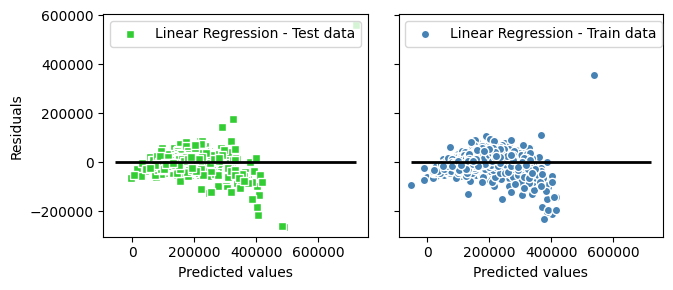

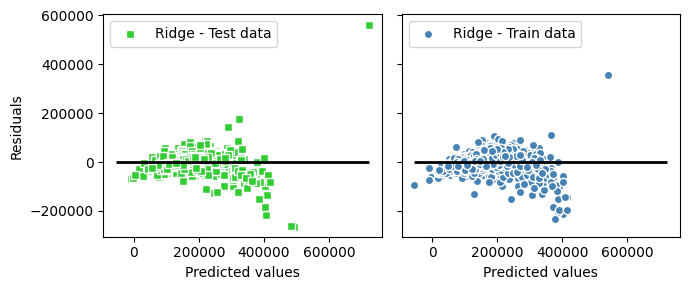

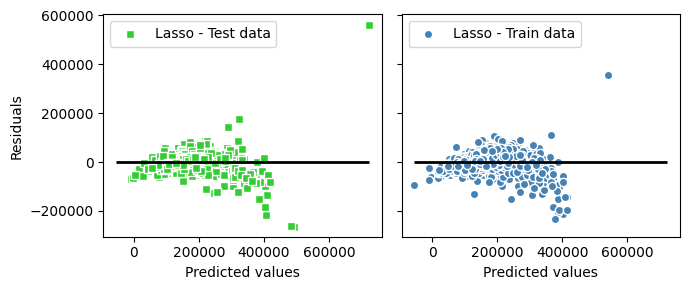

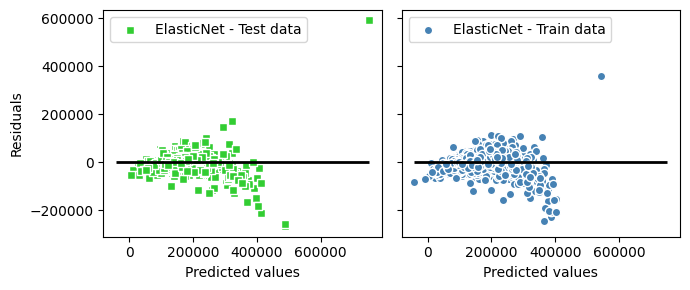

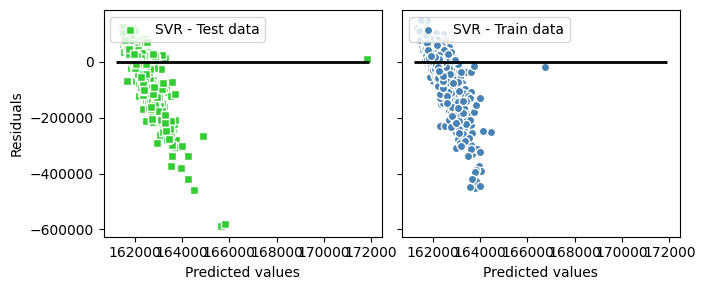

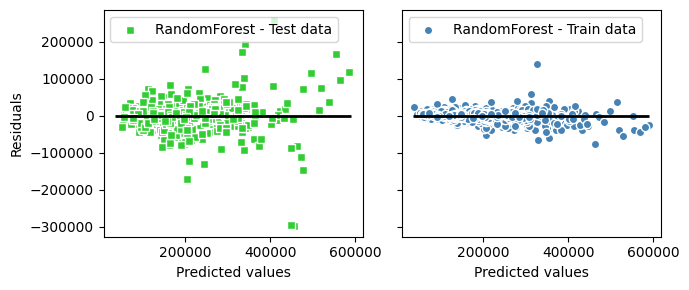

In [25]:
for title, model in models:
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    residual_plot(y_train,y_train_pred,
                  y_test, y_test_pred, title)

In [ ]:
# Mul